In [7]:
import torch
import torchvision
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

Загрузка модели Keypoint R-CNN

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=True)
model.eval().to(device)

KeypointRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640, 672, 704, 736, 768, 800), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.

In [ ]:
def get_keypoints_from_pil(img_pil, model, device, conf_threshold=0.9):
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
    output = outputs[0]
    scores = output['scores'].cpu().numpy()
    keypoints_all = output['keypoints'].cpu().numpy()      # [N, 17, 3]
    keypoints_scores = output['keypoints_scores'].cpu().numpy()  # [N, 17]

    # Человек с максимальной уверенностью, превышающей порог порога
    valid_idx = np.where(scores > conf_threshold)[0]
    if len(valid_idx) == 0:
        return None, None, None
    best_idx = valid_idx[np.argmax(scores[valid_idx])]
    # Координаты (x, y) и достоверности
    pts = keypoints_all[best_idx, :, :2]    # (17, 2)
    confs = keypoints_scores[best_idx]      # (17,)
    return pts, confs, scores[best_idx]

Функции сравнения (из предыдущего спринта)

In [10]:
pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:, :-1]

def align_affine(src_pts, dst_pts):
    """Аффинное преобразование src -> dst, возвращает преобразованные src_pts."""
    X = pad(src_pts)   # (17,3)
    Y = pad(dst_pts)   # (17,3)
    A, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    A[np.abs(A) < 1e-10] = 0
    transformed = unpad(np.dot(pad(src_pts), A))
    return transformed

def cosine_distance(pose1, pose2):
    """pose1, pose2 - одномерные векторы (34 элемента)"""
    v1 = pose1.flatten()
    v2 = pose2.flatten()
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return cos_sim

def weighted_distance(pose1, pose2, conf1):
    """
    pose1, pose2 - одномерные векторы координат (x1,y1,x2,y2,...)
    conf1 - достоверности ключевых точек (17 значений)
    """
    sum_conf = np.sum(conf1)
    if sum_conf == 0:
        return float('inf')
    weighted_sum = 0.0
    for i in range(len(pose1)):
        kp_idx = i // 2
        weighted_sum += conf1[kp_idx] * abs(pose1[i] - pose2[i])
    return weighted_sum / sum_conf

Обработка видео

In [ ]:
def process_video(video_path, model, device, frame_step=5, conf_threshold=0.9):
    """
    Извлекает кадры из видео, детектит ключевые точки.
    Возвращает списки: ключевые точки, достоверности, временные метки (в секундах).
    frame_step - обрабатываем каждый frame_step-й кадр.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    all_pts = []
    all_conf = []
    timestamps = []
    frame_count = 0

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        if frame_count % frame_step == 0:
            # Конвертируем BGR в RGB
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(frame_rgb)
            pts, confs, score = get_keypoints_from_pil(img_pil, model, device, conf_threshold)
            if pts is not None:
                all_pts.append(pts)
                all_conf.append(confs)
                timestamps.append(frame_count / fps)
        frame_count += 1
    cap.release()
    return all_pts, all_conf, timestamps


Сравнение двух видео

In [ ]:
ref_video = "data/dspr_cv_u1_diploma_spr3_2.mp4"      # видео коуча
user_video = "data/dspr_cv_u1_diploma_spr3_2_1.mp4"          # видео для проверки

# Параметры
frame_step = 10                   # обрабатываем каждый 10-й кадр
conf_threshold = 0.9              # порог уверенности детекции человека

# Данные из референсного видео
ref_pts_list, ref_conf_list, ref_time = process_video(ref_video, model, device, frame_step, conf_threshold)
print(f"Референс: обработано {len(ref_pts_list)} кадров")

# Данные из пользовательского видео
user_pts_list, user_conf_list, user_time = process_video(user_video, model, device, frame_step, conf_threshold)
print(f"Пользователь: обработано {len(user_pts_list)} кадров")

# Сопоставляем кадры по минимальной длине списка
n_frames = min(len(ref_pts_list), len(user_pts_list))
cos_scores = []
weighted_dists = []

for i in range(n_frames):
    ref_pts = ref_pts_list[i]
    user_pts = user_pts_list[i]
    user_conf = user_conf_list[i]

    # Аффинное преобразование позы пользователя к позе референса
    user_aligned = align_affine(user_pts, ref_pts)

    # Вычисляем метрики
    cos_val = cosine_distance(ref_pts.flatten(), user_aligned.flatten())
    w_dist = weighted_distance(user_aligned.flatten(), ref_pts.flatten(), user_conf)

    cos_scores.append(cos_val)
    weighted_dists.append(w_dist)

# Средние значения
mean_cos = np.mean(cos_scores)
mean_wdist = np.mean(weighted_dists)
print(f"Среднее косинусное сходство: {mean_cos:.4f}")
print(f"Среднее взвешенное расстояние: {mean_wdist:.2f}")

Референс: обработано 64 кадров
Пользователь: обработано 64 кадров
Среднее косинусное сходство: 1.0000
Среднее взвешенное расстояние: 0.00


 Визуализация изменения метрик во времени

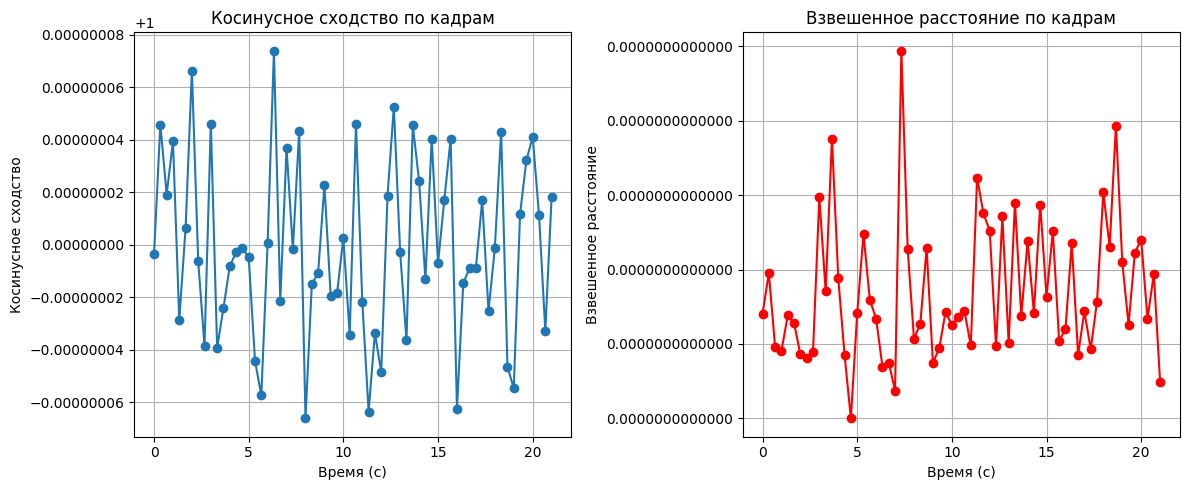

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ref_time[:n_frames], cos_scores, marker='o')
plt.xlabel('Время (с)')
plt.ylabel('Косинусное сходство')
plt.title('Косинусное сходство по кадрам')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')  # отключаем научную нотацию

plt.subplot(1,2,2)
plt.plot(ref_time[:n_frames], weighted_dists, marker='o', color='red')
plt.xlabel('Время (с)')
plt.ylabel('Взвешенное расстояние')
plt.title('Взвешенное расстояние по кадрам')
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# Результаты сравнения движений (анализ по видео)

## Косинусное сходство (слева)

- Косинус стремится к 1, что говорит о сильной форме-сходимости.
- Незначительные колебания объясняются шумом от модели и неидеальной съемкой.

## Взвешенное расстояние между позами (справа)

- Значения близки к нулю.
- Это означает, что позы совпадают почти идеально по координатам после выравнивания, что логично, поскольку визуально видео одно и то же.